In [ ]:
# Fig 1 - Study Area


In [ ]:
# Panel A

/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


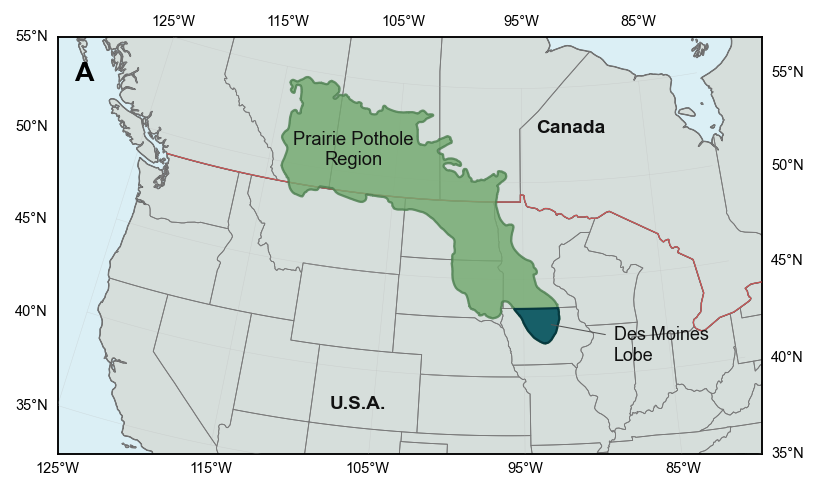

Saved:
../figures/figure1_panelA_regional_context.png
../figures/figure1_panelA_regional_context.pdf
../figures/figure1_panelA_regional_context.svg


In [15]:
# ============================================================
# Figure 1A: Regional context map
# Same as previous good version + real water layers in blue
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import box, LineString
import numpy as np
import os

ppr_path = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "gmannppr/gmannppr.shp"

fig_dir = Path("../figures")
fig_dir.mkdir(parents=True, exist_ok=True)

geo_crs = "EPSG:4326"
map_crs = "EPSG:5070"

countries_url = "zip+https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
admin1_url = "zip+https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
ocean_url = "zip+https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip"
lakes_url = "zip+https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip"

countries = gpd.read_file(countries_url).to_crs(geo_crs)
admin1 = gpd.read_file(admin1_url).to_crs(geo_crs)
ocean = gpd.read_file(ocean_url).to_crs(map_crs)
lakes = gpd.read_file(lakes_url).to_crs(map_crs)
ppr = gpd.read_file(ppr_path).to_crs(geo_crs)

countries_na = countries[countries["ADMIN"].isin(["United States of America", "Canada"])].copy()
admin1_na = admin1[admin1["admin"].isin(["United States of America", "Canada"])].copy()

usa = countries_na[countries_na["ADMIN"] == "United States of America"].copy()
canada = countries_na[countries_na["ADMIN"] == "Canada"].copy()

iowa = admin1_na[
    (admin1_na["admin"] == "United States of America") &
    (admin1_na["name"] == "Iowa")
].copy()

dml_display = gpd.overlay(
    ppr,
    iowa[["geometry"]],
    how="intersection",
    keep_geom_type=False
)

dml_display = (
    dml_display[dml_display.geometry.notna()]
    .explode(index_parts=False)
    .reset_index(drop=True)
)

usa_boundary = usa.geometry.union_all().boundary
canada_geom = canada.geometry.union_all()
us_canada_border = usa_boundary.intersection(canada_geom.buffer(0.01))

us_canada_border_gdf = gpd.GeoDataFrame(
    geometry=[us_canada_border],
    crs=geo_crs
)

countries_na = countries_na.to_crs(map_crs)
admin1_na = admin1_na.to_crs(map_crs)
ppr = ppr.to_crs(map_crs)
dml_display = dml_display.to_crs(map_crs)
us_canada_border_gdf = us_canada_border_gdf.to_crs(map_crs)

lon_min, lon_max = -125, -80
lat_min, lat_max = 35, 55

extent_geo = gpd.GeoDataFrame(
    geometry=[box(lon_min, lat_min, lon_max, lat_max)],
    crs=geo_crs
).to_crs(map_crs)

xmin, ymin, xmax, ymax = extent_geo.total_bounds

def make_graticule(lons, lats, lon_min, lon_max, lat_min, lat_max, n=300):
    lines = []
    for lon in lons:
        lines.append(LineString([(lon, lat) for lat in np.linspace(lat_min, lat_max, n)]))
    for lat in lats:
        lines.append(LineString([(lon, lat) for lon in np.linspace(lon_min, lon_max, n)]))
    return gpd.GeoDataFrame(geometry=lines, crs=geo_crs).to_crs(map_crs)

lon_ticks = [-125, -115, -105, -95, -85]
lat_ticks = [35, 40, 45, 50, 55]

graticule = make_graticule(
    lon_ticks, lat_ticks,
    lon_min, lon_max, lat_min, lat_max
)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.9,
    "savefig.dpi": 600,
    "figure.dpi": 150,
})

background_face = "#d6dedb"
water_face = "#dbeff5"
country_edge = "#4f4f4f"
admin_edge = "#7a7a7a"
border_red = "#e64b4b"

ppr_face = "#74aa70"
ppr_edge = "#4d7f50"

dml_face = "#155d68"
dml_edge = "#06383f"

label_color = "#111111"
leader_color = "#555555"
grid_color = "#b7b7b7"

fig, ax = plt.subplots(figsize=(5.3, 3.6))
ax.set_facecolor(background_face)

# Water layers only; clipped visually by panel frame
ocean.plot(ax=ax, facecolor=water_face, edgecolor="none", zorder=0)
lakes.plot(ax=ax, facecolor=water_face, edgecolor="none", zorder=0)

countries_na.plot(
    ax=ax,
    facecolor=background_face,
    edgecolor=country_edge,
    linewidth=0.65,
    zorder=1
)

admin1_na.boundary.plot(
    ax=ax,
    color=admin_edge,
    linewidth=0.42,
    zorder=2
)

graticule.plot(
    ax=ax,
    color=grid_color,
    linewidth=0.25,
    alpha=0.35,
    zorder=3
)

us_canada_border_gdf.plot(
    ax=ax,
    color=border_red,
    linewidth=0.5,
    alpha=0.85,
    zorder=4
)

ppr.plot(
    ax=ax,
    facecolor=ppr_face,
    edgecolor=ppr_edge,
    linewidth=1.1,
    alpha=0.82,
    zorder=5
)

dml_display.plot(
    ax=ax,
    facecolor=dml_face,
    edgecolor=dml_edge,
    linewidth=1.05,
    alpha=0.98,
    zorder=6
)

label_points_geo = gpd.GeoDataFrame(
    {
        "label": ["Prairie Pothole\nRegion", "Canada", "U.S.A."],
        "fontsize": [8.8, 9.2, 9.2],
        "fontweight": ["normal", "bold", "bold"],
    },
    geometry=gpd.points_from_xy(
        [-108.5, -91.0, -106.0],
        [51.2, 52.8, 38.2]
    ),
    crs=geo_crs
).to_crs(map_crs)

for _, row in label_points_geo.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        row["label"],
        fontsize=row["fontsize"],
        fontweight=row["fontweight"],
        ha="center",
        va="center",
        color=label_color,
        zorder=8
    )

dml_centroid = dml_display.geometry.union_all().centroid

ax.annotate(
    "Des Moines\nLobe",
    xy=(dml_centroid.x + 4.0e4, dml_centroid.y - 1.0e4),
    xytext=(dml_centroid.x + 4.2e5, dml_centroid.y - 1.3e5),
    fontsize=8.6,
    ha="left",
    va="center",
    color=label_color,
    arrowprops=dict(
        arrowstyle="-",
        color=leader_color,
        linewidth=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    zorder=9
)

ax.text(
    0.025, 0.94, "A",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
    zorder=10
)

def project_point(lon, lat):
    pt = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([lon], [lat]),
        crs=geo_crs
    ).to_crs(map_crs)
    return pt.geometry.iloc[0].x, pt.geometry.iloc[0].y

for lon in lon_ticks:
    x_top, _ = project_point(lon, lat_max)
    x_bot, _ = project_point(lon, lat_min)

    ax.text(x_top, ymax + (ymax - ymin) * 0.020, f"{abs(lon):.0f}°W",
            ha="center", va="bottom", fontsize=7, color="black")

    ax.text(x_bot, ymin - (ymax - ymin) * 0.020, f"{abs(lon):.0f}°W",
            ha="center", va="top", fontsize=7, color="black")

for lat in lat_ticks:
    _, y_left = project_point(lon_min, lat)
    _, y_right = project_point(lon_max, lat)

    ax.text(xmin - (xmax - xmin) * 0.014, y_left, f"{lat:.0f}°N",
            ha="right", va="center", fontsize=7, color="black")

    ax.text(xmax + (xmax - xmin) * 0.014, y_right, f"{lat:.0f}°N",
            ha="left", va="center", fontsize=7, color="black")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.9)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout(pad=0.25)

out_png = fig_dir / "figure1_panelA_regional_context.png"
out_pdf = fig_dir / "figure1_panelA_regional_context.pdf"
out_svg = fig_dir / "figure1_panelA_regional_context.svg"

fig.savefig(out_png, bbox_inches="tight", dpi=600, facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved:\n{out_png}\n{out_pdf}\n{out_svg}")

In [ ]:
# Panel B

/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


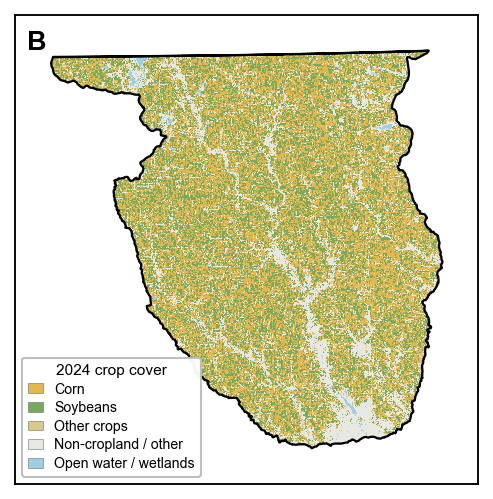

Saved:
../figures/figure1_panelB_dml_2024_cropscape_clipped.png
../figures/figure1_panelB_dml_2024_cropscape_clipped.pdf
../figures/figure1_panelB_dml_2024_cropscape_clipped.svg


In [13]:
# ============================================================
# Figure 1B: Des Moines Lobe 2024 crop cover
# USDA CropScape / CDL background, clipped to DML boundary
# ============================================================

import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
from rasterio import features
from affine import Affine
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pathlib import Path
import numpy as np
import os

# ----------------------------
# Paths
# ----------------------------

cdl_path = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "Cropscape/2024_30m_cdls/2024_30m_cdls.tif"

dml_path = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "IA_physiographic_regions/DML_boundaries.shp"

fig_dir = Path("../figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Load DML boundary
# ----------------------------

dml = gpd.read_file(dml_path)
dml["geometry"] = dml.geometry.make_valid()
dml = dml[dml.geometry.notna() & ~dml.geometry.is_empty].copy()

# ----------------------------
# Efficiently read only DML window
# ----------------------------

with rasterio.open(cdl_path) as src:
    dml_proj = dml.to_crs(src.crs)

    dml_buffer = dml_proj.copy()
    dml_buffer["geometry"] = dml_buffer.geometry.buffer(20000)

    xmin, ymin, xmax, ymax = dml_buffer.total_bounds

    window = from_bounds(xmin, ymin, xmax, ymax, transform=src.transform)
    window = window.round_offsets().round_lengths()

    cdl = src.read(1, window=window)
    transform = src.window_transform(window)
    raster_crs = src.crs
    nodata = src.nodata

# ----------------------------
# Reclassify CDL
# ----------------------------

reclass = np.zeros_like(cdl, dtype=np.uint8)

if nodata is not None:
    reclass[cdl == nodata] = 0

water_wetland_codes = [83, 87, 92, 111]
reclass[np.isin(cdl, water_wetland_codes)] = 5

noncrop_codes = [
    63, 64, 65,
    81, 82,
    88,
    112, 121, 122, 123, 124,
    131,
    141, 142, 143,
    152,
    176,
    190, 195
]
reclass[np.isin(cdl, noncrop_codes)] = 4

valid = cdl > 0
if nodata is not None:
    valid = valid & (cdl != nodata)

reclass[
    valid
    & ~np.isin(cdl, [1, 5])
    & ~np.isin(cdl, water_wetland_codes)
    & ~np.isin(cdl, noncrop_codes)
] = 3

reclass[cdl == 1] = 1   # corn
reclass[cdl == 5] = 2   # soybeans

# ----------------------------
# Mask to exact DML boundary
# ----------------------------

h, w = reclass.shape

dml_mask = features.rasterize(
    [(geom, 1) for geom in dml_proj.geometry],
    out_shape=(h, w),
    transform=transform,
    fill=0,
    dtype="uint8",
    all_touched=True
)

reclass = np.where(dml_mask == 1, reclass, 0)
reclass_masked = np.ma.masked_where(reclass == 0, reclass)

# ----------------------------
# Colors
# ----------------------------

class_colors = {
    0: "#ffffff00",
    1: "#e5b84f",  # corn
    2: "#78a95f",  # soybeans
    3: "#d9c98b",  # other crops
    4: "#e8e8e3",  # non-cropland / other
    5: "#9ecfe0",  # open water / wetlands
}

class_labels = {
    1: "Corn",
    2: "Soybeans",
    3: "Other crops",
    4: "Non-cropland / other",
    5: "Open water / wetlands",
}

cmap = ListedColormap([class_colors[i] for i in range(0, 6)])
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

# ----------------------------
# Plot
# ----------------------------

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.9,
    "savefig.dpi": 600,
    "figure.dpi": 150,
})

fig, ax = plt.subplots(figsize=(3.1, 3.3))
ax.set_facecolor("white")

xmin = transform.c
xmax = transform.c + w * transform.a
ymax = transform.f
ymin = transform.f + h * transform.e

ax.imshow(
    reclass_masked,
    cmap=cmap,
    norm=norm,
    extent=[xmin, xmax, ymin, ymax],
    interpolation="nearest",
    zorder=1
)

dml_proj.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.1,
    zorder=5
)

ax.text(
    0.025, 0.965, "B",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
    zorder=10
)

legend_order = [1, 2, 3, 4, 5]
handles = [
    Patch(
        facecolor=class_colors[i],
        edgecolor="#666666",
        linewidth=0.25,
        label=class_labels[i]
    )
    for i in legend_order
]

ax.legend(
    handles=handles,
    loc="lower left",
    frameon=True,
    framealpha=0.96,
    facecolor="white",
    edgecolor="#bdbdbd",
    fontsize=6.8,
    title="2024 crop cover",
    title_fontsize=7.4,
    handlelength=1.0,
    handleheight=0.7,
    borderpad=0.45,
    labelspacing=0.32
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.9)

plt.tight_layout(pad=0.05)

# ----------------------------
# Save
# ----------------------------

out_png = fig_dir / "figure1_panelB_dml_2024_cropscape_clipped.png"
out_pdf = fig_dir / "figure1_panelB_dml_2024_cropscape_clipped.pdf"
out_svg = fig_dir / "figure1_panelB_dml_2024_cropscape_clipped.svg"

fig.savefig(out_png, bbox_inches="tight", dpi=600, facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved:\n{out_png}\n{out_pdf}\n{out_svg}")

In [ ]:
# Panel C

/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


NWI features retained in DML: 43,085
WETLAND_TYPE
Freshwater Emergent Wetland          32358
Freshwater Forested/Shrub Wetland    10727
Name: count, dtype: int64
count    8094.000000
mean        1.276117
std         3.384890
min         0.000000
25%         0.000000
50%         0.145740
75%         0.871612
max        60.966529
Name: wet_pct, dtype: float64


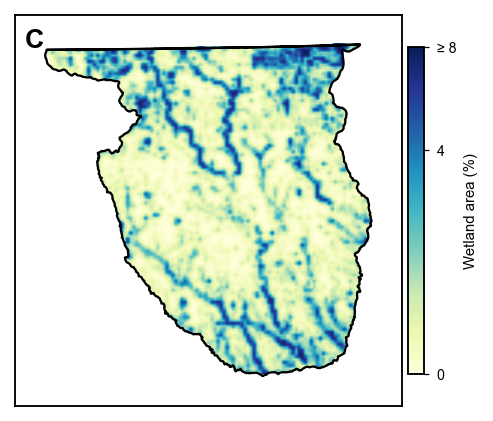

Saved:
../figures/figure1_panelC_dml_current_wetland_density.png
../figures/figure1_panelC_dml_current_wetland_density.pdf
../figures/figure1_panelC_dml_current_wetland_density.svg


In [12]:
# ============================================================
# Figure 1C: Current wetland density across the Des Moines Lobe
# NWI palustrine-like wetlands only; masked to DML boundary
# ============================================================

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from pathlib import Path
from shapely.geometry import box
from scipy.ndimage import gaussian_filter
from rasterio import features
from affine import Affine
import warnings
import os

# ----------------------------
# Paths
# ----------------------------

dml_path = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "IA_physiographic_regions/DML_boundaries.shp"

nwi_path = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "NWI/IA_geopackage_wetlands.gpkg"

fig_dir = Path("../figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Settings
# ----------------------------

target_crs = "EPSG:5070"
nwi_layer = "IA_Wetlands"

cell_size = 2000      # meters
buffer_m = 20000      # match Panel B
smooth_sigma = 0.5
vmax = 8              # suggested compromise

keep_types = [
    "Freshwater Emergent Wetland",
    "Freshwater Forested/Shrub Wetland"
]

# ----------------------------
# Load data
# ----------------------------

dml = gpd.read_file(dml_path).to_crs(target_crs)
dml["geometry"] = dml.geometry.make_valid()
dml = dml[dml.geometry.notna() & ~dml.geometry.is_empty].copy()

dml_buffer = dml.copy()
dml_buffer["geometry"] = dml_buffer.geometry.buffer(buffer_m)

nwi = gpd.read_file(nwi_path, layer=nwi_layer).to_crs(target_crs)
nwi["geometry"] = nwi.geometry.make_valid()
nwi = nwi[nwi.geometry.notna() & ~nwi.geometry.is_empty].copy()

# Exclude riverine, lacustrine/lake, ponds, and other
nwi = nwi[nwi["WETLAND_TYPE"].isin(keep_types)].copy()

# Clip to DML
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    nwi_dml = gpd.clip(nwi, dml)

print(f"NWI features retained in DML: {len(nwi_dml):,}")
print(nwi_dml["WETLAND_TYPE"].value_counts())

# ----------------------------
# Build grid over buffered DML extent
# ----------------------------

minx, miny, maxx, maxy = dml_buffer.total_bounds

x_edges = np.arange(minx, maxx + cell_size, cell_size)
y_edges = np.arange(miny, maxy + cell_size, cell_size)

grid_cells, rows, cols = [], [], []

for j, y0 in enumerate(y_edges[:-1]):
    for i, x0 in enumerate(x_edges[:-1]):
        grid_cells.append(box(x0, y0, x0 + cell_size, y0 + cell_size))
        rows.append(j)
        cols.append(i)

grid = gpd.GeoDataFrame(
    {"row": rows, "col": cols},
    geometry=grid_cells,
    crs=target_crs
)

# Use DML-only cells for density calculation
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    grid_calc = gpd.clip(grid, dml).reset_index(drop=True)

grid_calc["grid_id"] = grid_calc.index
grid_calc["cell_area_m2"] = grid_calc.geometry.area

# ----------------------------
# Intersect wetlands with grid
# ----------------------------

if len(nwi_dml) > 0:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        joined = gpd.overlay(
            grid_calc[["grid_id", "row", "col", "cell_area_m2", "geometry"]],
            nwi_dml[["geometry"]],
            how="intersection",
            keep_geom_type=False
        )

    joined["wet_area_m2"] = joined.geometry.area
    wet_area = joined.groupby("grid_id")["wet_area_m2"].sum()
    grid_calc["wet_area_m2"] = grid_calc["grid_id"].map(wet_area).fillna(0)
else:
    grid_calc["wet_area_m2"] = 0.0

grid_calc["wet_pct"] = 100 * grid_calc["wet_area_m2"] / grid_calc["cell_area_m2"]
grid_calc["wet_pct"] = grid_calc["wet_pct"].clip(lower=0)

print(grid_calc["wet_pct"].describe())

# ----------------------------
# Convert grid to array
# ----------------------------

n_cols = len(x_edges) - 1
n_rows = len(y_edges) - 1

arr = np.full((n_rows, n_cols), np.nan, dtype=float)

for _, r in grid_calc.iterrows():
    arr[int(r["row"]), int(r["col"])] = r["wet_pct"]

arr = np.clip(arr, 0, vmax)

# Smooth only valid DML cells
valid = np.isfinite(arr)
filled = np.where(valid, arr, 0)

weights = gaussian_filter(valid.astype(float), sigma=smooth_sigma)
smooth = gaussian_filter(filled, sigma=smooth_sigma)

with np.errstate(invalid="ignore", divide="ignore"):
    arr_smooth = np.where(weights > 0, smooth / weights, np.nan)

arr_smooth = np.clip(arr_smooth, 0, vmax)

# ----------------------------
# Mask final surface to exact DML boundary
# ----------------------------

transform = Affine(
    cell_size, 0, x_edges[0],
    0, cell_size, y_edges[0]
)

dml_mask = features.rasterize(
    [(geom, 1) for geom in dml.geometry],
    out_shape=(n_rows, n_cols),
    transform=transform,
    fill=0,
    dtype="uint8",
    all_touched=True
)

arr_smooth = np.where(dml_mask == 1, arr_smooth, np.nan)
arr_smooth = np.ma.masked_invalid(arr_smooth)

# ----------------------------
# Plot
# ----------------------------

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.9,
    "savefig.dpi": 600,
    "figure.dpi": 150,
})

fig, ax = plt.subplots(figsize=(3.1, 3.3))
ax.set_facecolor("white")

cmap = plt.cm.YlGnBu.copy()
cmap.set_bad("#ffffff00")

norm = PowerNorm(gamma=0.55, vmin=0, vmax=vmax)

extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

im = ax.imshow(
    arr_smooth,
    extent=extent,
    origin="lower",
    cmap=cmap,
    norm=norm,
    interpolation="bilinear",
    zorder=1
)

dml.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.1,
    zorder=5
)

ax.text(
    0.025, 0.965, "C",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
    zorder=10
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.040,
    pad=0.015
)

cbar.set_label("Wetland area (%)", fontsize=7.2)
cbar.ax.tick_params(labelsize=6.8, length=2.5, width=0.6)
cbar.set_ticks([0, 4, 8])
cbar.set_ticklabels(["0", "4", "≥ 8"])

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.9)

plt.tight_layout(pad=0.05)

# ----------------------------
# Save
# ----------------------------

out_png = fig_dir / "figure1_panelC_dml_current_wetland_density.png"
out_pdf = fig_dir / "figure1_panelC_dml_current_wetland_density.pdf"
out_svg = fig_dir / "figure1_panelC_dml_current_wetland_density.svg"

fig.savefig(out_png, bbox_inches="tight", dpi=600, facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved:\n{out_png}\n{out_pdf}\n{out_svg}")

In [6]:
print(nwi.columns)

Index(['ATTRIBUTE', 'WETLAND_TYPE', 'ACRES', 'NWI_ID', 'geometry'], dtype='object')


In [7]:
import geopandas as gpd
import os

nwi_path = str(Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "NWI/IA_geopackage_wetlands.gpkg")

# Load layer explicitly
nwi = gpd.read_file(nwi_path, layer="IA_Wetlands")

# Check unique values and counts
print("\n=== WETLAND_TYPE value counts ===")
print(nwi["WETLAND_TYPE"].value_counts(dropna=False))

print("\n=== Unique WETLAND_TYPE values ===")
print(sorted(nwi["WETLAND_TYPE"].dropna().unique()))


=== WETLAND_TYPE value counts ===
WETLAND_TYPE
Riverine                             215487
Freshwater Emergent Wetland          212801
Freshwater Pond                      161071
Freshwater Forested/Shrub Wetland    116459
Lake                                   2024
Other                                     5
Name: count, dtype: int64

=== Unique WETLAND_TYPE values ===
['Freshwater Emergent Wetland', 'Freshwater Forested/Shrub Wetland', 'Freshwater Pond', 'Lake', 'Other', 'Riverine']


In [ ]:
# make 2-part figure

/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


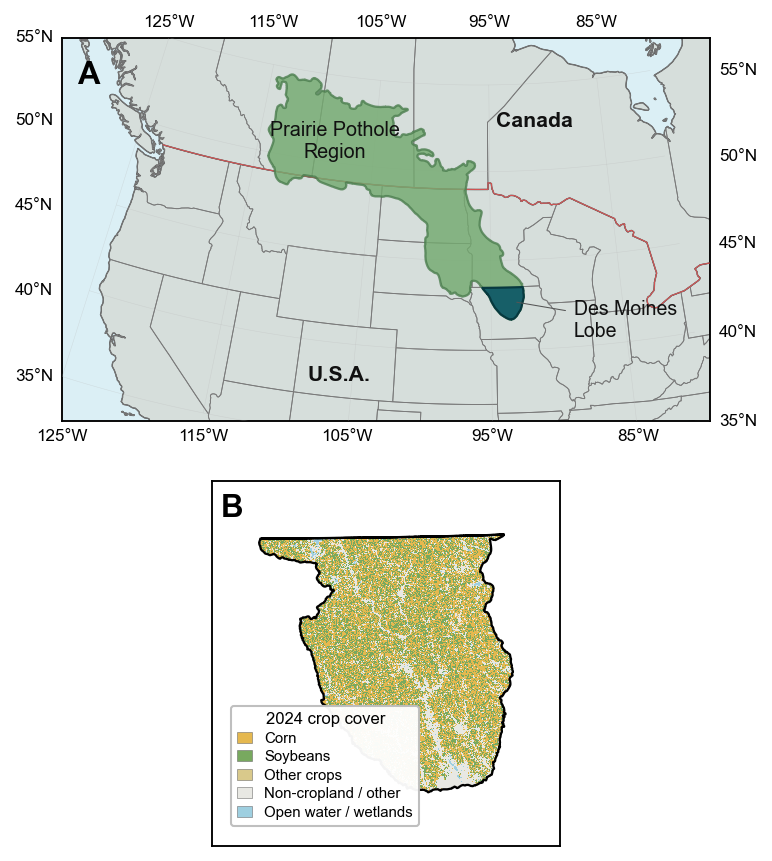

Saved:
../figures/figure1_panels_A_B_combined.png
../figures/figure1_panels_A_B_combined.pdf
../figures/figure1_panels_A_B_combined.svg
../figures/figure1_panel_A_context.pdf
../figures/figure1_panel_A_context.svg
../figures/figure1_panel_A_context.png
../figures/figure1_panel_B_crop_cover.pdf
../figures/figure1_panel_B_crop_cover.svg
../figures/figure1_panel_B_crop_cover.png


In [19]:
# ============================================================
# Figure 1: Study area and crop cover context
# Exports combined figure plus separate Panels A and B
# ============================================================

import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from rasterio import features
from rasterio.windows import from_bounds
from shapely.geometry import box, LineString
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

fig_dir = Path("../figures")
fig_dir.mkdir(parents=True, exist_ok=True)

ppr_path = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "gmannppr/gmannppr.shp"

cdl_path = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "Cropscape/2024_30m_cdls/2024_30m_cdls.tif"

dml_path = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "IA_physiographic_regions/DML_boundaries.shp"

# Natural Earth
countries_url = "zip+https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
admin1_url = "zip+https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
ocean_url = "zip+https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip"
lakes_url = "zip+https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip"

# ------------------------------------------------------------
# Aesthetics
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8.5,
    "axes.linewidth": 0.9,
    "savefig.dpi": 600,
    "figure.dpi": 150,
})

geo_crs = "EPSG:4326"
map_crs = "EPSG:5070"

panel_label_kwargs = dict(
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
    zorder=20
)

# ============================================================
# Helper functions
# ============================================================

def clean_gdf(gdf):
    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.make_valid()
    return gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()


def make_graticule(lons, lats, lon_min, lon_max, lat_min, lat_max, n=300):
    lines = []

    for lon in lons:
        lines.append(LineString([(lon, lat) for lat in np.linspace(lat_min, lat_max, n)]))

    for lat in lats:
        lines.append(LineString([(lon, lat) for lon in np.linspace(lon_min, lon_max, n)]))

    return gpd.GeoDataFrame(geometry=lines, crs=geo_crs).to_crs(map_crs)


def project_point(lon, lat):
    pt = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([lon], [lat]),
        crs=geo_crs
    ).to_crs(map_crs)
    return pt.geometry.iloc[0].x, pt.geometry.iloc[0].y


def style_map_axis(ax, lw=0.9):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect("equal", adjustable="box")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(lw)


def save_axis(fig, ax, out_base, pad_inches=0.03):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox = ax.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())

    fig.savefig(
        fig_dir / f"{out_base}.pdf",
        bbox_inches=bbox.expanded(1.01, 1.01),
        pad_inches=pad_inches,
        facecolor="white"
    )

    fig.savefig(
        fig_dir / f"{out_base}.svg",
        bbox_inches=bbox.expanded(1.01, 1.01),
        pad_inches=pad_inches,
        facecolor="white"
    )

    fig.savefig(
        fig_dir / f"{out_base}.png",
        bbox_inches=bbox.expanded(1.01, 1.01),
        pad_inches=pad_inches,
        dpi=600,
        facecolor="white"
    )

    # 👉 ADD THIS
    fig.savefig(
        fig_dir / f"{out_base}.jpg",
        bbox_inches=bbox.expanded(1.01, 1.01),
        pad_inches=pad_inches,
        dpi=600,
        facecolor="white"
    )

# ============================================================
# Prepare common DML extent for Panel B
# ============================================================

with rasterio.open(cdl_path) as src:
    bc_crs = src.crs

dml = clean_gdf(gpd.read_file(dml_path)).to_crs(bc_crs)

buffer_m = 20000
dml_buffer = dml.copy()
dml_buffer["geometry"] = dml_buffer.geometry.buffer(buffer_m)
bc_minx, bc_miny, bc_maxx, bc_maxy = dml_buffer.total_bounds

# ============================================================
# Create figure layout
# ============================================================

fig = plt.figure(figsize=(7.2, 7.0))

gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[1.05, 1.0],
    hspace=0.16
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[1, 0])

# ============================================================
# Panel A: Regional context
# ============================================================

countries = gpd.read_file(countries_url).to_crs(geo_crs)
admin1 = gpd.read_file(admin1_url).to_crs(geo_crs)
ocean = gpd.read_file(ocean_url).to_crs(map_crs)
lakes = gpd.read_file(lakes_url).to_crs(map_crs)
ppr = gpd.read_file(ppr_path).to_crs(geo_crs)

countries_na = countries[countries["ADMIN"].isin(["United States of America", "Canada"])].copy()
admin1_na = admin1[admin1["admin"].isin(["United States of America", "Canada"])].copy()

usa = countries_na[countries_na["ADMIN"] == "United States of America"].copy()
canada = countries_na[countries_na["ADMIN"] == "Canada"].copy()

iowa = admin1_na[
    (admin1_na["admin"] == "United States of America") &
    (admin1_na["name"] == "Iowa")
].copy()

dml_display = gpd.overlay(
    ppr,
    iowa[["geometry"]],
    how="intersection",
    keep_geom_type=False
)

dml_display = clean_gdf(dml_display).explode(index_parts=False).reset_index(drop=True)

usa_boundary = usa.geometry.union_all().boundary
canada_geom = canada.geometry.union_all()
us_canada_border = usa_boundary.intersection(canada_geom.buffer(0.01))

us_canada_border_gdf = gpd.GeoDataFrame(
    geometry=[us_canada_border],
    crs=geo_crs
)

countries_na = countries_na.to_crs(map_crs)
admin1_na = admin1_na.to_crs(map_crs)
ppr = ppr.to_crs(map_crs)
dml_display = dml_display.to_crs(map_crs)
us_canada_border_gdf = us_canada_border_gdf.to_crs(map_crs)

lon_min, lon_max = -125, -80
lat_min, lat_max = 35, 55

extent_geo = gpd.GeoDataFrame(
    geometry=[box(lon_min, lat_min, lon_max, lat_max)],
    crs=geo_crs
).to_crs(map_crs)

a_xmin, a_ymin, a_xmax, a_ymax = extent_geo.total_bounds

lon_ticks = [-125, -115, -105, -95, -85]
lat_ticks = [35, 40, 45, 50, 55]

graticule = make_graticule(lon_ticks, lat_ticks, lon_min, lon_max, lat_min, lat_max)

background_face = "#d6dedb"
water_face = "#dbeff5"
country_edge = "#4f4f4f"
admin_edge = "#7a7a7a"
border_red = "#e64b4b"
ppr_face = "#74aa70"
ppr_edge = "#4d7f50"
dml_face = "#155d68"
dml_edge = "#06383f"
grid_color = "#b7b7b7"

ax_a.set_facecolor(background_face)

ocean.plot(ax=ax_a, facecolor=water_face, edgecolor="none", zorder=0)
lakes.plot(ax=ax_a, facecolor=water_face, edgecolor="none", zorder=0)

countries_na.plot(
    ax=ax_a,
    facecolor=background_face,
    edgecolor=country_edge,
    linewidth=0.65,
    zorder=1
)

admin1_na.boundary.plot(
    ax=ax_a,
    color=admin_edge,
    linewidth=0.42,
    zorder=2
)

graticule.plot(
    ax=ax_a,
    color=grid_color,
    linewidth=0.25,
    alpha=0.35,
    zorder=3
)

us_canada_border_gdf.plot(
    ax=ax_a,
    color=border_red,
    linewidth=0.5,
    alpha=0.85,
    zorder=4
)

ppr.plot(
    ax=ax_a,
    facecolor=ppr_face,
    edgecolor=ppr_edge,
    linewidth=1.1,
    alpha=0.82,
    zorder=5
)

dml_display.plot(
    ax=ax_a,
    facecolor=dml_face,
    edgecolor=dml_edge,
    linewidth=1.05,
    alpha=0.98,
    zorder=6
)

label_points_geo = gpd.GeoDataFrame(
    {
        "label": ["Prairie Pothole\nRegion", "Canada", "U.S.A."],
        "fontsize": [9.5, 10.2, 10.2],
        "fontweight": ["normal", "bold", "bold"],
    },
    geometry=gpd.points_from_xy(
        [-108.5, -91.0, -106.0],
        [51.2, 52.8, 38.2]
    ),
    crs=geo_crs
).to_crs(map_crs)

for _, row in label_points_geo.iterrows():
    ax_a.text(
        row.geometry.x,
        row.geometry.y,
        row["label"],
        fontsize=row["fontsize"],
        fontweight=row["fontweight"],
        ha="center",
        va="center",
        color="#111111",
        zorder=8
    )

dml_centroid = dml_display.geometry.union_all().centroid

ax_a.annotate(
    "Des Moines\nLobe",
    xy=(dml_centroid.x + 4.0e4, dml_centroid.y - 1.0e4),
    xytext=(dml_centroid.x + 4.2e5, dml_centroid.y - 1.3e5),
    fontsize=9.4,
    ha="left",
    va="center",
    color="#111111",
    arrowprops=dict(
        arrowstyle="-",
        color="#555555",
        linewidth=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    zorder=9
)

ax_a.text(0.025, 0.94, "A", transform=ax_a.transAxes, **panel_label_kwargs)

for lon in lon_ticks:
    x_top, _ = project_point(lon, lat_max)
    x_bot, _ = project_point(lon, lat_min)

    ax_a.text(
        x_top, a_ymax + (a_ymax - a_ymin) * 0.020,
        f"{abs(lon):.0f}°W",
        ha="center", va="bottom",
        fontsize=8.2,
        color="black"
    )

    ax_a.text(
        x_bot, a_ymin - (a_ymax - a_ymin) * 0.020,
        f"{abs(lon):.0f}°W",
        ha="center", va="top",
        fontsize=8.2,
        color="black"
    )

for lat in lat_ticks:
    _, y_left = project_point(lon_min, lat)
    _, y_right = project_point(lon_max, lat)

    ax_a.text(
        a_xmin - (a_xmax - a_xmin) * 0.014,
        y_left,
        f"{lat:.0f}°N",
        ha="right",
        va="center",
        fontsize=8.2,
        color="black"
    )

    ax_a.text(
        a_xmax + (a_xmax - a_xmin) * 0.014,
        y_right,
        f"{lat:.0f}°N",
        ha="left",
        va="center",
        fontsize=8.2,
        color="black"
    )

ax_a.set_xlim(a_xmin, a_xmax)
ax_a.set_ylim(a_ymin, a_ymax)
style_map_axis(ax_a)

# ============================================================
# Panel B: 2024 crop cover clipped to DML
# ============================================================

with rasterio.open(cdl_path) as src:
    window = from_bounds(bc_minx, bc_miny, bc_maxx, bc_maxy, transform=src.transform)
    window = window.round_offsets().round_lengths()

    cdl = src.read(1, window=window)
    cdl_transform = src.window_transform(window)
    cdl_nodata = src.nodata

reclass = np.zeros_like(cdl, dtype=np.uint8)

if cdl_nodata is not None:
    reclass[cdl == cdl_nodata] = 0

water_wetland_codes = [83, 87, 92, 111]
noncrop_codes = [
    63, 64, 65,
    81, 82,
    88,
    112, 121, 122, 123, 124,
    131,
    141, 142, 143,
    152,
    176,
    190, 195
]

reclass[np.isin(cdl, water_wetland_codes)] = 5
reclass[np.isin(cdl, noncrop_codes)] = 4

valid = cdl > 0
if cdl_nodata is not None:
    valid = valid & (cdl != cdl_nodata)

reclass[
    valid
    & ~np.isin(cdl, [1, 5])
    & ~np.isin(cdl, water_wetland_codes)
    & ~np.isin(cdl, noncrop_codes)
] = 3

reclass[cdl == 1] = 1
reclass[cdl == 5] = 2

h, w = reclass.shape

dml_mask = features.rasterize(
    [(geom, 1) for geom in dml.geometry],
    out_shape=(h, w),
    transform=cdl_transform,
    fill=0,
    dtype="uint8",
    all_touched=True
)

reclass = np.where(dml_mask == 1, reclass, 0)
reclass_masked = np.ma.masked_where(reclass == 0, reclass)

class_colors = {
    0: "#ffffff00",
    1: "#e5b84f",
    2: "#78a95f",
    3: "#d9c98b",
    4: "#e8e8e3",
    5: "#9ecfe0",
}

class_labels = {
    1: "Corn",
    2: "Soybeans",
    3: "Other crops",
    4: "Non-cropland / other",
    5: "Open water / wetlands",
}

cmap_b = ListedColormap([class_colors[i] for i in range(0, 6)])
norm_b = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap_b.N)

b_xmin = cdl_transform.c
b_xmax = cdl_transform.c + w * cdl_transform.a
b_ymax = cdl_transform.f
b_ymin = cdl_transform.f + h * cdl_transform.e

ax_b.set_facecolor("white")

ax_b.imshow(
    reclass_masked,
    cmap=cmap_b,
    norm=norm_b,
    extent=[b_xmin, b_xmax, b_ymin, b_ymax],
    interpolation="nearest",
    zorder=1
)

dml.plot(
    ax=ax_b,
    facecolor="none",
    edgecolor="black",
    linewidth=1.1,
    zorder=5
)

ax_b.text(0.025, 0.965, "B", transform=ax_b.transAxes, **panel_label_kwargs)

legend_order = [1, 2, 3, 4, 5]
handles = [
    Patch(
        facecolor=class_colors[i],
        edgecolor="#666666",
        linewidth=0.25,
        label=class_labels[i]
    )
    for i in legend_order
]

ax_b.legend(
    handles=handles,
    loc="lower left",
    bbox_to_anchor=(0.035, 0.035),
    frameon=True,
    framealpha=0.96,
    facecolor="white",
    edgecolor="#bdbdbd",
    fontsize=7.2,
    title="2024 crop cover",
    title_fontsize=8.0,
    handlelength=1.0,
    handleheight=0.75,
    borderpad=0.40,
    labelspacing=0.30
)

# Add breathing room around the DML footprint so the label and legend do not crowd the map
x_pad = (bc_maxx - bc_minx) * 0.08
y_pad = (bc_maxy - bc_miny) * 0.10

ax_b.set_xlim(bc_minx - x_pad, bc_maxx + x_pad)
ax_b.set_ylim(bc_miny - y_pad, bc_maxy + y_pad)

style_map_axis(ax_b)

# ============================================================
# Save combined figure and separate panels
# ============================================================

out_png = fig_dir / "figure1_panels_A_B_combined.png"
out_pdf = fig_dir / "figure1_panels_A_B_combined.pdf"
out_svg = fig_dir / "figure1_panels_A_B_combined.svg"

fig.savefig(out_png, bbox_inches="tight", dpi=600, facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

out_jpg = fig_dir / "figure1_panels_A_B_combined.jpg"

fig.savefig(out_jpg, bbox_inches="tight", dpi=600, facecolor="white")

save_axis(fig, ax_a, "figure1_panel_A_context")
save_axis(fig, ax_b, "figure1_panel_B_crop_cover")

plt.show()

print("Saved:")
print(out_png)
print(out_pdf)
print(out_svg)
print(fig_dir / "figure1_panel_A_context.pdf")
print(fig_dir / "figure1_panel_A_context.svg")
print(fig_dir / "figure1_panel_A_context.png")
print(fig_dir / "figure1_panel_B_crop_cover.pdf")
print(fig_dir / "figure1_panel_B_crop_cover.svg")
print(fig_dir / "figure1_panel_B_crop_cover.png")

In [ ]:
# make 3-part figure

/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/DML_wetlands_11262025/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


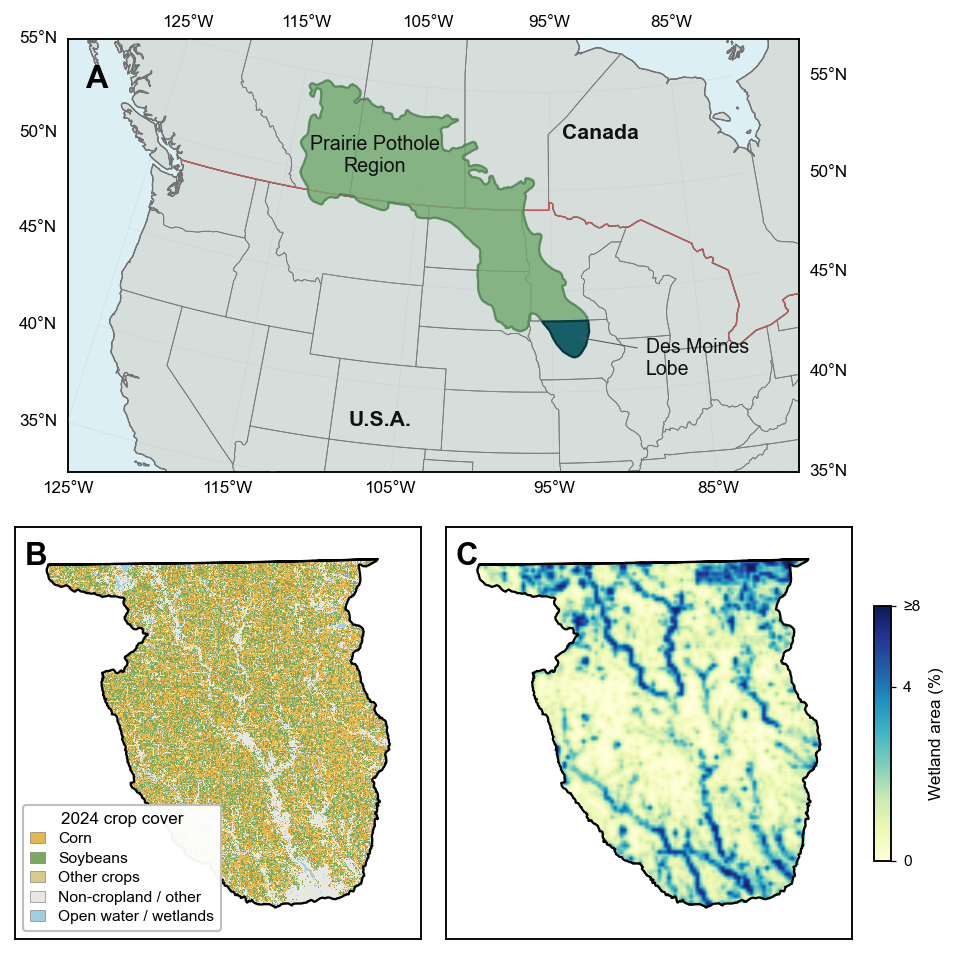

Saved:
../figures/figure1_study_area_three_panel.png
../figures/figure1_study_area_three_panel.pdf
../figures/figure1_study_area_three_panel.svg


In [15]:
# ============================================================
# Figure 1: Study area and landscape context
# Panel A full width; Panels B and C matched below
# ============================================================

import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from affine import Affine
from matplotlib.colors import BoundaryNorm, ListedColormap, PowerNorm
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from rasterio import features
from rasterio.windows import from_bounds
from scipy.ndimage import gaussian_filter
from shapely.geometry import box, LineString
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

fig_dir = Path("../figures")
fig_dir.mkdir(parents=True, exist_ok=True)

ppr_path = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "gmannppr/gmannppr.shp"

cdl_path = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "Cropscape/2024_30m_cdls/2024_30m_cdls.tif"

dml_path = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "IA_physiographic_regions/DML_boundaries.shp"

nwi_path = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "NWI/IA_geopackage_wetlands.gpkg"

# Natural Earth
countries_url = "zip+https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
admin1_url = "zip+https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
ocean_url = "zip+https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip"
lakes_url = "zip+https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip"

# ------------------------------------------------------------
# Global aesthetics
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8.5,
    "axes.linewidth": 0.9,
    "savefig.dpi": 600,
    "figure.dpi": 150,
})

geo_crs = "EPSG:4326"
map_crs = "EPSG:5070"

panel_label_kwargs = dict(
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
    zorder=20
)

# ============================================================
# Helper functions
# ============================================================

def clean_gdf(gdf):
    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.make_valid()
    return gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()


def make_graticule(lons, lats, lon_min, lon_max, lat_min, lat_max, n=300):
    lines = []

    for lon in lons:
        lines.append(LineString([(lon, lat) for lat in np.linspace(lat_min, lat_max, n)]))

    for lat in lats:
        lines.append(LineString([(lon, lat) for lon in np.linspace(lon_min, lon_max, n)]))

    return gpd.GeoDataFrame(geometry=lines, crs=geo_crs).to_crs(map_crs)


def project_point(lon, lat):
    pt = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([lon], [lat]),
        crs=geo_crs
    ).to_crs(map_crs)
    return pt.geometry.iloc[0].x, pt.geometry.iloc[0].y


def style_map_axis(ax, lw=0.9):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect("equal", adjustable="box")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(lw)


# ============================================================
# Prepare common DML extent for Panels B and C
# ============================================================

with rasterio.open(cdl_path) as src:
    bc_crs = src.crs
    cdl_transform_full = src.transform
    cdl_nodata = src.nodata

dml = clean_gdf(gpd.read_file(dml_path)).to_crs(bc_crs)

buffer_m = 20000
dml_buffer = dml.copy()
dml_buffer["geometry"] = dml_buffer.geometry.buffer(buffer_m)
bc_minx, bc_miny, bc_maxx, bc_maxy = dml_buffer.total_bounds

# ============================================================
# Create figure layout
# ============================================================

fig = plt.figure(figsize=(7.2, 7.8))

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[1.05, 1.0],
    width_ratios=[1, 1],
    hspace=0.13,
    wspace=0.06
)

ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])

# ============================================================
# Panel A: Regional context
# ============================================================

countries = gpd.read_file(countries_url).to_crs(geo_crs)
admin1 = gpd.read_file(admin1_url).to_crs(geo_crs)
ocean = gpd.read_file(ocean_url).to_crs(map_crs)
lakes = gpd.read_file(lakes_url).to_crs(map_crs)
ppr = gpd.read_file(ppr_path).to_crs(geo_crs)

countries_na = countries[countries["ADMIN"].isin(["United States of America", "Canada"])].copy()
admin1_na = admin1[admin1["admin"].isin(["United States of America", "Canada"])].copy()

usa = countries_na[countries_na["ADMIN"] == "United States of America"].copy()
canada = countries_na[countries_na["ADMIN"] == "Canada"].copy()

iowa = admin1_na[
    (admin1_na["admin"] == "United States of America") &
    (admin1_na["name"] == "Iowa")
].copy()

dml_display = gpd.overlay(
    ppr,
    iowa[["geometry"]],
    how="intersection",
    keep_geom_type=False
)

dml_display = clean_gdf(dml_display).explode(index_parts=False).reset_index(drop=True)

usa_boundary = usa.geometry.union_all().boundary
canada_geom = canada.geometry.union_all()
us_canada_border = usa_boundary.intersection(canada_geom.buffer(0.01))

us_canada_border_gdf = gpd.GeoDataFrame(
    geometry=[us_canada_border],
    crs=geo_crs
)

countries_na = countries_na.to_crs(map_crs)
admin1_na = admin1_na.to_crs(map_crs)
ppr = ppr.to_crs(map_crs)
dml_display = dml_display.to_crs(map_crs)
us_canada_border_gdf = us_canada_border_gdf.to_crs(map_crs)

lon_min, lon_max = -125, -80
lat_min, lat_max = 35, 55

extent_geo = gpd.GeoDataFrame(
    geometry=[box(lon_min, lat_min, lon_max, lat_max)],
    crs=geo_crs
).to_crs(map_crs)

a_xmin, a_ymin, a_xmax, a_ymax = extent_geo.total_bounds

lon_ticks = [-125, -115, -105, -95, -85]
lat_ticks = [35, 40, 45, 50, 55]

graticule = make_graticule(lon_ticks, lat_ticks, lon_min, lon_max, lat_min, lat_max)

background_face = "#d6dedb"
water_face = "#dbeff5"
country_edge = "#4f4f4f"
admin_edge = "#7a7a7a"
border_red = "#e64b4b"
ppr_face = "#74aa70"
ppr_edge = "#4d7f50"
dml_face = "#155d68"
dml_edge = "#06383f"
grid_color = "#b7b7b7"

ax_a.set_facecolor(background_face)

ocean.plot(ax=ax_a, facecolor=water_face, edgecolor="none", zorder=0)
lakes.plot(ax=ax_a, facecolor=water_face, edgecolor="none", zorder=0)

countries_na.plot(
    ax=ax_a,
    facecolor=background_face,
    edgecolor=country_edge,
    linewidth=0.65,
    zorder=1
)

admin1_na.boundary.plot(
    ax=ax_a,
    color=admin_edge,
    linewidth=0.42,
    zorder=2
)

graticule.plot(
    ax=ax_a,
    color=grid_color,
    linewidth=0.25,
    alpha=0.35,
    zorder=3
)

us_canada_border_gdf.plot(
    ax=ax_a,
    color=border_red,
    linewidth=0.5,
    alpha=0.85,
    zorder=4
)

ppr.plot(
    ax=ax_a,
    facecolor=ppr_face,
    edgecolor=ppr_edge,
    linewidth=1.1,
    alpha=0.82,
    zorder=5
)

dml_display.plot(
    ax=ax_a,
    facecolor=dml_face,
    edgecolor=dml_edge,
    linewidth=1.05,
    alpha=0.98,
    zorder=6
)

label_points_geo = gpd.GeoDataFrame(
    {
        "label": ["Prairie Pothole\nRegion", "Canada", "U.S.A."],
        "fontsize": [9.5, 10.2, 10.2],
        "fontweight": ["normal", "bold", "bold"],
    },
    geometry=gpd.points_from_xy(
        [-108.5, -91.0, -106.0],
        [51.2, 52.8, 38.2]
    ),
    crs=geo_crs
).to_crs(map_crs)

for _, row in label_points_geo.iterrows():
    ax_a.text(
        row.geometry.x,
        row.geometry.y,
        row["label"],
        fontsize=row["fontsize"],
        fontweight=row["fontweight"],
        ha="center",
        va="center",
        color="#111111",
        zorder=8
    )

dml_centroid = dml_display.geometry.union_all().centroid

ax_a.annotate(
    "Des Moines\nLobe",
    xy=(dml_centroid.x + 4.0e4, dml_centroid.y - 1.0e4),
    xytext=(dml_centroid.x + 4.2e5, dml_centroid.y - 1.3e5),
    fontsize=9.4,
    ha="left",
    va="center",
    color="#111111",
    arrowprops=dict(
        arrowstyle="-",
        color="#555555",
        linewidth=0.5,
        shrinkA=2,
        shrinkB=2
    ),
    zorder=9
)

ax_a.text(0.025, 0.94, "A", transform=ax_a.transAxes, **panel_label_kwargs)

for lon in lon_ticks:
    x_top, _ = project_point(lon, lat_max)
    x_bot, _ = project_point(lon, lat_min)

    ax_a.text(
        x_top, a_ymax + (a_ymax - a_ymin) * 0.020,
        f"{abs(lon):.0f}°W",
        ha="center", va="bottom",
        fontsize=8.2,
        color="black"
    )

    ax_a.text(
        x_bot, a_ymin - (a_ymax - a_ymin) * 0.020,
        f"{abs(lon):.0f}°W",
        ha="center", va="top",
        fontsize=8.2,
        color="black"
    )

for lat in lat_ticks:
    _, y_left = project_point(lon_min, lat)
    _, y_right = project_point(lon_max, lat)

    ax_a.text(
        a_xmin - (a_xmax - a_xmin) * 0.014,
        y_left,
        f"{lat:.0f}°N",
        ha="right",
        va="center",
        fontsize=8.2,
        color="black"
    )

    ax_a.text(
        a_xmax + (a_xmax - a_xmin) * 0.014,
        y_right,
        f"{lat:.0f}°N",
        ha="left",
        va="center",
        fontsize=8.2,
        color="black"
    )

ax_a.set_xlim(a_xmin, a_xmax)
ax_a.set_ylim(a_ymin, a_ymax)
style_map_axis(ax_a)

# ============================================================
# Panel B: 2024 crop cover clipped to DML
# ============================================================

with rasterio.open(cdl_path) as src:
    window = from_bounds(bc_minx, bc_miny, bc_maxx, bc_maxy, transform=src.transform)
    window = window.round_offsets().round_lengths()

    cdl = src.read(1, window=window)
    cdl_transform = src.window_transform(window)
    cdl_nodata = src.nodata

reclass = np.zeros_like(cdl, dtype=np.uint8)

if cdl_nodata is not None:
    reclass[cdl == cdl_nodata] = 0

water_wetland_codes = [83, 87, 92, 111]
noncrop_codes = [
    63, 64, 65,
    81, 82,
    88,
    112, 121, 122, 123, 124,
    131,
    141, 142, 143,
    152,
    176,
    190, 195
]

reclass[np.isin(cdl, water_wetland_codes)] = 5
reclass[np.isin(cdl, noncrop_codes)] = 4

valid = cdl > 0
if cdl_nodata is not None:
    valid = valid & (cdl != cdl_nodata)

reclass[
    valid
    & ~np.isin(cdl, [1, 5])
    & ~np.isin(cdl, water_wetland_codes)
    & ~np.isin(cdl, noncrop_codes)
] = 3

reclass[cdl == 1] = 1
reclass[cdl == 5] = 2

h, w = reclass.shape

dml_mask = features.rasterize(
    [(geom, 1) for geom in dml.geometry],
    out_shape=(h, w),
    transform=cdl_transform,
    fill=0,
    dtype="uint8",
    all_touched=True
)

reclass = np.where(dml_mask == 1, reclass, 0)
reclass_masked = np.ma.masked_where(reclass == 0, reclass)

class_colors = {
    0: "#ffffff00",
    1: "#e5b84f",
    2: "#78a95f",
    3: "#d9c98b",
    4: "#e8e8e3",
    5: "#9ecfe0",
}

class_labels = {
    1: "Corn",
    2: "Soybeans",
    3: "Other crops",
    4: "Non-cropland / other",
    5: "Open water / wetlands",
}

cmap_b = ListedColormap([class_colors[i] for i in range(0, 6)])
norm_b = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap_b.N)

b_xmin = cdl_transform.c
b_xmax = cdl_transform.c + w * cdl_transform.a
b_ymax = cdl_transform.f
b_ymin = cdl_transform.f + h * cdl_transform.e

ax_b.set_facecolor("white")

ax_b.imshow(
    reclass_masked,
    cmap=cmap_b,
    norm=norm_b,
    extent=[b_xmin, b_xmax, b_ymin, b_ymax],
    interpolation="nearest",
    zorder=1
)

dml.plot(
    ax=ax_b,
    facecolor="none",
    edgecolor="black",
    linewidth=1.1,
    zorder=5
)

ax_b.text(0.025, 0.965, "B", transform=ax_b.transAxes, **panel_label_kwargs)

legend_order = [1, 2, 3, 4, 5]
handles = [
    Patch(
        facecolor=class_colors[i],
        edgecolor="#666666",
        linewidth=0.25,
        label=class_labels[i]
    )
    for i in legend_order
]

ax_b.legend(
    handles=handles,
    loc="lower left",
    frameon=True,
    framealpha=0.96,
    facecolor="white",
    edgecolor="#bdbdbd",
    fontsize=7.5,
    title="2024 crop cover",
    title_fontsize=8.2,
    handlelength=1.0,
    handleheight=0.75,
    borderpad=0.45,
    labelspacing=0.34
)

ax_b.set_xlim(bc_minx, bc_maxx)
ax_b.set_ylim(bc_miny, bc_maxy)
style_map_axis(ax_b)

# ============================================================
# Panel C: Current wetland density clipped to DML
# ============================================================

target_crs = bc_crs
nwi_layer = "IA_Wetlands"
cell_size = 2000
smooth_sigma = 0.5
vmax = 8

keep_types = [
    "Freshwater Emergent Wetland",
    "Freshwater Forested/Shrub Wetland"
]

nwi = gpd.read_file(nwi_path, layer=nwi_layer).to_crs(target_crs)
nwi = clean_gdf(nwi)
nwi = nwi[nwi["WETLAND_TYPE"].isin(keep_types)].copy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    nwi_dml = gpd.clip(nwi, dml)

x_edges = np.arange(bc_minx, bc_maxx + cell_size, cell_size)
y_edges = np.arange(bc_miny, bc_maxy + cell_size, cell_size)

grid_cells, rows, cols = [], [], []

for j, y0 in enumerate(y_edges[:-1]):
    for i, x0 in enumerate(x_edges[:-1]):
        grid_cells.append(box(x0, y0, x0 + cell_size, y0 + cell_size))
        rows.append(j)
        cols.append(i)

grid = gpd.GeoDataFrame(
    {"row": rows, "col": cols},
    geometry=grid_cells,
    crs=target_crs
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    grid_calc = gpd.clip(grid, dml).reset_index(drop=True)

grid_calc["grid_id"] = grid_calc.index
grid_calc["cell_area_m2"] = grid_calc.geometry.area

if len(nwi_dml) > 0:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        joined = gpd.overlay(
            grid_calc[["grid_id", "row", "col", "cell_area_m2", "geometry"]],
            nwi_dml[["geometry"]],
            how="intersection",
            keep_geom_type=False
        )

    joined["wet_area_m2"] = joined.geometry.area
    wet_area = joined.groupby("grid_id")["wet_area_m2"].sum()
    grid_calc["wet_area_m2"] = grid_calc["grid_id"].map(wet_area).fillna(0)
else:
    grid_calc["wet_area_m2"] = 0.0

grid_calc["wet_pct"] = 100 * grid_calc["wet_area_m2"] / grid_calc["cell_area_m2"]
grid_calc["wet_pct"] = grid_calc["wet_pct"].clip(lower=0)

n_cols = len(x_edges) - 1
n_rows = len(y_edges) - 1

arr = np.full((n_rows, n_cols), np.nan, dtype=float)

for _, r in grid_calc.iterrows():
    arr[int(r["row"]), int(r["col"])] = r["wet_pct"]

arr = np.clip(arr, 0, vmax)

valid = np.isfinite(arr)
filled = np.where(valid, arr, 0)

weights = gaussian_filter(valid.astype(float), sigma=smooth_sigma)
smooth = gaussian_filter(filled, sigma=smooth_sigma)

with np.errstate(invalid="ignore", divide="ignore"):
    arr_smooth = np.where(weights > 0, smooth / weights, np.nan)

arr_smooth = np.clip(arr_smooth, 0, vmax)

c_transform = Affine(
    cell_size, 0, x_edges[0],
    0, cell_size, y_edges[0]
)

dml_mask_c = features.rasterize(
    [(geom, 1) for geom in dml.geometry],
    out_shape=(n_rows, n_cols),
    transform=c_transform,
    fill=0,
    dtype="uint8",
    all_touched=True
)

arr_smooth = np.where(dml_mask_c == 1, arr_smooth, np.nan)
arr_smooth = np.ma.masked_invalid(arr_smooth)

cmap_c = plt.cm.YlGnBu.copy()
cmap_c.set_bad("#ffffff00")

norm_c = PowerNorm(gamma=0.55, vmin=0, vmax=vmax)

ax_c.set_facecolor("white")

im_c = ax_c.imshow(
    arr_smooth,
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    origin="lower",
    cmap=cmap_c,
    norm=norm_c,
    interpolation="bilinear",
    zorder=1
)

dml.plot(
    ax=ax_c,
    facecolor="none",
    edgecolor="black",
    linewidth=1.1,
    zorder=5
)

ax_c.text(0.025, 0.965, "C", transform=ax_c.transAxes, **panel_label_kwargs)

# Inset colorbar so Panel C remains same size as Panel B
cax = inset_axes(
    ax_c,
    width="4.0%",
    height="62%",
    loc="center right",
    bbox_to_anchor=(0.095, 0, 1, 1),
    bbox_transform=ax_c.transAxes,
    borderpad=0
)

cbar = fig.colorbar(im_c, cax=cax)
cbar.set_label("Wetland area (%)", fontsize=8.2)
cbar.ax.tick_params(labelsize=7.5, length=2.5, width=0.6)
cbar.set_ticks([0, 4, 8])
cbar.set_ticklabels(["0", "4", "≥8"])

ax_c.set_xlim(bc_minx, bc_maxx)
ax_c.set_ylim(bc_miny, bc_maxy)
style_map_axis(ax_c)

# ============================================================
# Save
# ============================================================

out_png = fig_dir / "figure1_study_area_three_panel.png"
out_pdf = fig_dir / "figure1_study_area_three_panel.pdf"
out_svg = fig_dir / "figure1_study_area_three_panel.svg"

fig.savefig(out_png, bbox_inches="tight", dpi=600, facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved:\n{out_png}\n{out_pdf}\n{out_svg}")